In [2]:
#installing libraries
import pandas as pd


df = pd.read_csv("Retail_Data_Transactions.csv")
df.head()

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   customer_id  125000 non-null  str  
 1   trans_date   125000 non-null  str  
 2   tran_amount  125000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 2.9 MB


customer_id    0
trans_date     0
tran_amount    0
dtype: int64

In [4]:
df_1 = pd.read_csv("Retail_Data_Response.csv")
df_1.head()

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1


In [5]:
df_1.info()
df_1.describe()
df_1.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6884 entries, 0 to 6883
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  6884 non-null   str  
 1   response     6884 non-null   int64
dtypes: int64(1), str(1)
memory usage: 107.7 KB


customer_id    0
response       0
dtype: int64

In [6]:
#merge two dataframes
r_trans = pd.merge(df, df_1, how= 'left')
r_trans

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [7]:
#changing datatype into datetime

r_trans["trans_date"] = pd.to_datetime(r_trans["trans_date"])
r_trans

C:\Users\hp\AppData\Local\Temp\ipykernel_17476\2847999660.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  r_trans["trans_date"] = pd.to_datetime(r_trans["trans_date"])


,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1.0
1,CS4768,2015-03-15,39,1.0
2,CS2122,2013-02-26,52,0.0
3,CS1217,2011-11-16,99,0.0
4,CS1850,2013-11-20,78,0.0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0.0
124996,CS7232,2014-08-19,38,0.0
124997,CS8731,2014-11-28,42,0.0
124998,CS8133,2013-12-14,13,0.0


In [8]:
#removing null values
r_trans.isnull().sum()

customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [9]:
r_trans = r_trans.dropna()
r_trans.describe()
r_trans.isnull().sum()

customer_id    0
trans_date     0
tran_amount    0
response       0
dtype: int64

In [10]:
# converting responce datatype from float to integer
r_trans["response"] = r_trans["response"].astype(int)
r_trans

,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1
1,CS4768,2015-03-15,39,1
2,CS2122,2013-02-26,52,0
3,CS1217,2011-11-16,99,0
4,CS1850,2013-11-20,78,0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0
124996,CS7232,2014-08-19,38,0
124997,CS8731,2014-11-28,42,0
124998,CS8133,2013-12-14,13,0


In [11]:
#exporting cleaned data

r_trans.to_csv("Retail_Data_Cleaned.csv", index= False)
r_trans

#loading cleaned data
r_trans =pd.read_csv("Retail_Data_Cleaned.csv")
r_trans

PermissionError: [Errno 13] Permission denied: 'Retail_Data_Cleaned.csv'

In [ ]:
#Count unique customers
trans_amount = r_trans['customer_id'].nunique()
trans_amount

6884

In [ ]:
#calculating total spent by each customer
customer_sales = r_trans.groupby('customer_id')['tran_amount'].sum()
customer_sales
customer_sales =customer_sales.reset_index()
customer_sales

,customer_id,tran_amount
0,CS1112,1012
1,CS1113,1490
2,CS1114,1432
3,CS1115,1659
4,CS1116,857
...,...,...
6879,CS8996,582
6880,CS8997,543
6881,CS8998,624
6882,CS8999,383


In [ ]:
#average spent by each customer
average_sales = r_trans.groupby(customer_sales['customer_id'])['tran_amount'].mean()
average_sales

customer_id
CS1112     35.0
CS1113     39.0
CS1114     52.0
CS1115     99.0
CS1116     78.0
          ...  
CS8996     76.0
CS8997    103.0
CS8998     73.0
CS8999     43.0
CS9000     86.0
Name: tran_amount, Length: 6884, dtype: float64

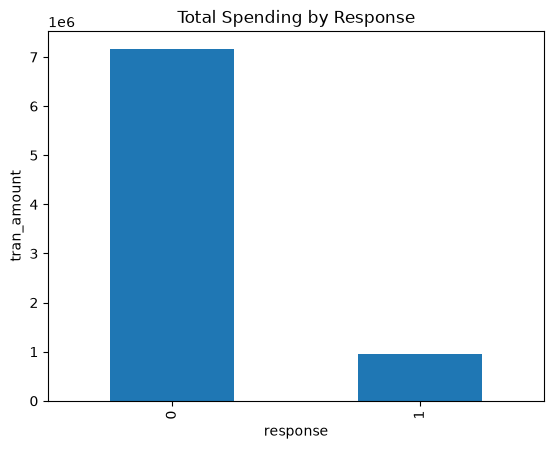

In [ ]:
#creating a bar plot on response vs tran_amount
import matplotlib.pyplot as plt
import seaborn as sns
r_trans.groupby('response')['tran_amount'].sum().plot(kind='bar')
plt.xlabel("response")
plt.ylabel("tran_amount")
plt.title("Total Spending by Response")
plt.show()

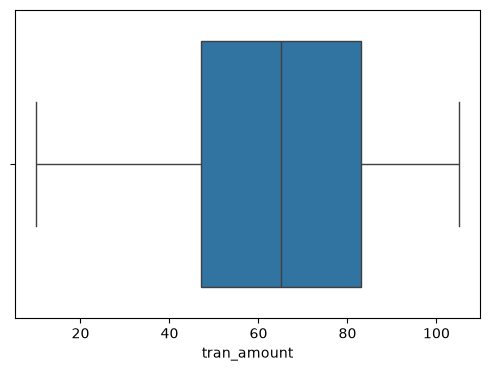

In [ ]:
#boxplot for tran_amount
plt.figure (figsize=(6,4))
sns.boxplot(x=r_trans['tran_amount'])
plt.show()

In [ ]:
#checking for outliers
# z_score

from scipy import stats
import numpy as np

#calculating z_scores

z_scores = stats.zscore (r_trans['tran_amount'])

#set a threshold
threshold = 3

outliers = z_scores > threshold
print(r_trans[outliers])



Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [ ]:
#checking for outliers
# z_score

from scipy import stats
import numpy as np

#calculating z_scores

z_scores = stats.zscore (r_trans['response'])

#set a threshold
threshold = 3

outliers = z_scores > threshold
print(r_trans[outliers])


Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [ ]:
# Which year has the highest transaction amounts?

yearly_Sales= r_trans.groupby('trans_date')['tran_amount'].sum()
yearly_Sales= yearly_Sales.sort_values(ascending=False).reset_index().head()
yearly_Sales

,trans_date,tran_amount
0,2011-07-16,8791
1,2014-05-20,8108
2,2012-11-15,8054
3,2011-08-11,7938
4,2011-09-18,7866


In [ ]:
r_trans['trans_date'].dtype
r_trans['trans_date'] = pd.to_datetime(r_trans['trans_date'])
print(r_trans['trans_date'].dtype)

datetime64[us]


In [ ]:
# Creating new column
r_trans['month'] = r_trans['trans_date'].dt.month
r_trans

,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1,2
1,CS4768,2015-03-15,39,1,3
2,CS2122,2013-02-26,52,0,2
3,CS1217,2011-11-16,99,0,11
4,CS1850,2013-11-20,78,0,11
...,...,...,...,...,...
124964,CS8433,2011-06-26,64,0,6
124965,CS7232,2014-08-19,38,0,8
124966,CS8731,2014-11-28,42,0,11
124967,CS8133,2013-12-14,13,0,12


In [ ]:
# Which 5 month has the highet transaction?
monthly_sales= r_trans.groupby('month')['tran_amount'].sum()
monthly_sales= monthly_sales.sort_values(ascending=False).reset_index().head(5)
monthly_sales

,month,tran_amount
0,8,726775
1,10,725058
2,1,724089
3,7,717011
4,12,709795


In [ ]:
# What is the maximum and minimum transaction amounts?

r_trans['tran_amount'].min(), r_trans['tran_amount'].max()

(np.int64(10), np.int64(105))

In [ ]:
# What is the maximum and minimum transaction amounts?

r_trans[r_trans['response'] == 1].shape[0]

13842

In [ ]:
# Do responding customers spend more?
r_trans.groupby('response')['tran_amount'].mean()


response
0    64.492248
1    69.032510
Name: tran_amount, dtype: float64

In [15]:
# Customers having highest num of orders

customer_counts= r_trans['customer_id'].value_counts().reset_index()
customer_counts.columns=['customer_id','count']
top_5_cus= customer_counts.sort_values(by='count', ascending=False).head(5)
top_5_cus

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS5109,35
4,CS3013,35


C:\Users\hp\AppData\Local\Temp\ipykernel_17476\3225393170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_cus, x='customer_id', y='count',  palette='Set1')


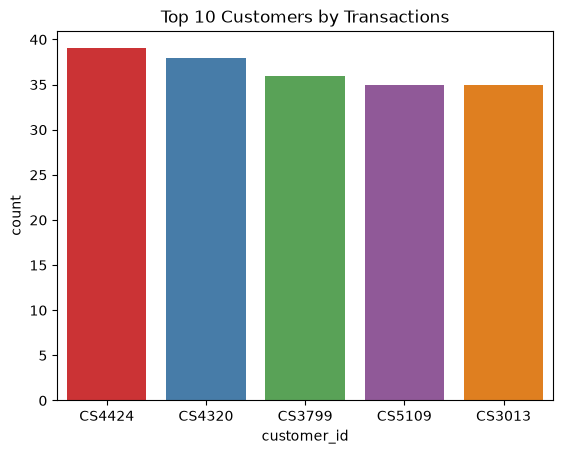

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top_5_cus, x='customer_id', y='count',  palette='Set1')
plt.title("Top 10 Customers by Transactions")
plt.show()

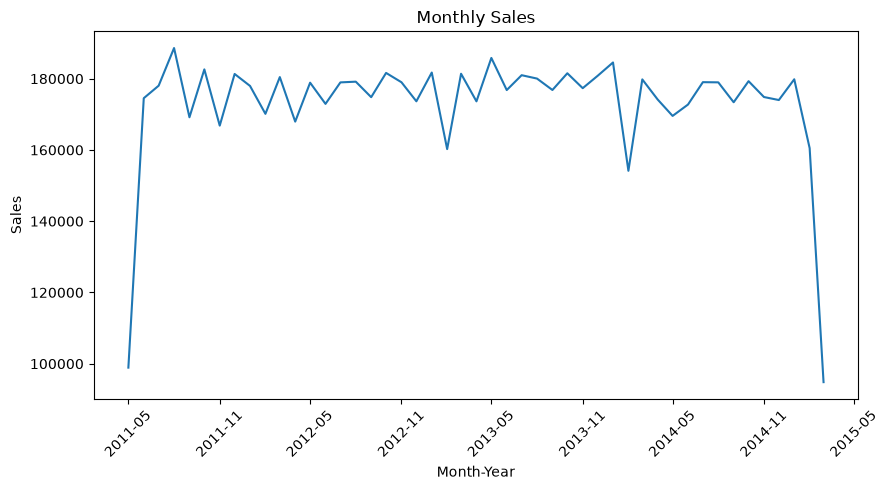

In [26]:
# Time series analysis

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

r_trans['month_year'] = r_trans['trans_date'].dt.to_period('M')
monthly_sales = r_trans.groupby('month_year')['tran_amount'].sum()

# Convert the PeriodIndex to DateTimeIndex
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(9,5))  # Increase the size of the figure
plt.plot(monthly_sales.index, monthly_sales.values)  # Plot the data
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format the x-axis labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Set the x-axis interval
plt.xlabel('Month-Year')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.xticks(rotation=45)  # Rotate the x-axis labels
plt.tight_layout()  # Adjust the layout for better visibility
plt.show()
